# SPATIAL INTELLIGENCE — SINGLE-FLOOR PLAN (Marsella / Unité d'Habitation)
## Grid-Based Approach — `Marsella_grids.obj`

Analyze a **single floor plan** of the Marsella building using a **pre-defined grid**
(`Marsella_grids.obj`) as the spatial decomposition.  This notebook combines:

- The **grid workflow** from the team notebooks (`00_Ahmad Grids.ipynb`): the building
  geometry is transformed into pre-defined rectangular cells — each cell becomes a graph node.
- The **complete Spatial Intelligence analysis** from
  `Simplified_NB_Marsella_MultiFloor_Spatial_Intelligence.ipynb`, adapted for a
  **single floor** (no stair connections, no floor stacking).

**Input:** `Marsella_grids.obj` — 187 grid lines (21 horizontal + 166 vertical) that
define the spatial analysis cells of the Marsella floor plan.  The file is exported from
Rhino with the floor plan in the OBJ XZ-plane (OBJ-Y = 20, constant).  We map it to
topologicpy plan space as `plan_X = OBJ_X`, `plan_Y = −OBJ_Z`.

**Method:**
1. Parse the 187 pre-defined grid lines (`cstype/curv` blocks) from `Marsella_grids.obj`.
2. Identify horizontal (constant Z) and vertical (constant X) lines.
3. Compute the 20 × 165 = **3 300 rectangular cells** between adjacent grid lines.
4. Each cell centroid → graph node; adjacent cells → graph edge (4-connected grid).
5. Run all Spatial Intelligence metrics on this single-floor graph.

**Outputs:** `assets_marsella_grids_single_floor/`


## 1. Import the needed libraries

In [1]:
import os, math, time
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

# Static PNG via kaleido — avoids VS Code WebGL crash
pio.renderers.default = "png"

from topologicpy.Vertex import Vertex
from topologicpy.Edge import Edge
from topologicpy.Wire import Wire
from topologicpy.Face import Face
from topologicpy.Cluster import Cluster
from topologicpy.Topology import Topology
from topologicpy.Dictionary import Dictionary
from topologicpy.Helper import Helper
from topologicpy.Graph import Graph
from topologicpy.Color import Color

e:\IAAC Local GIT Repositories\Graph ML - Environment\.env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Check the TopologicPy version

In [2]:
print("This notebook requires topologicpy version 0.9.18 or newer.")
print(Helper.Version())

This notebook requires topologicpy version 0.9.18 or newer.
The version that you are using (0.9.43) is OLDER than the latest version (0.9.50) from PyPI. Please consider upgrading to the latest version.


## 3. Configuration

In [3]:
renderer             = "png"
INTERACTIVE_RENDERER = "png"   # set to "browser" for interactive 3D

BASE_DIR          = "E:/IAAC Local GIT Repositories/Graph ML - Environment/Final_Project"
BUILDING_OBJ_PATH = os.path.join(BASE_DIR, "3D-Models",
                                  "Marsella_3-Floor-Plans_SIMPLIFIED.obj")
GRID_OBJ_PATH     = os.path.join(BASE_DIR, "3D-Models", "Marsella_grids.obj")
ASSETS_DIR        = os.path.join(BASE_DIR, "Notebooks", "assets",
                                  "assets_marsella_grids_single_floor")
os.makedirs(ASSETS_DIR, exist_ok=True)

for _p in [BUILDING_OBJ_PATH, GRID_OBJ_PATH]:
    if not os.path.exists(_p):
        raise FileNotFoundError(f"File not found: {_p}")

# Coordinate system of the simplified building OBJ (as seen by topologicpy):
#   Vertex.X -> plan X  [228.75, 361.25]
#   Vertex.Y -> plan Y depth  [5.25, 28.75]
#   Vertex.Z -> floor level  ~1 / 4 / 8  (bins to FLOOR_LEVELS [0,4,8])

# Target floor: use Z=1 (floor 1).  FLOOR_LEVELS = [0, 4, 8] in the Simplified_NB
# maps floor-1 faces (Z_centroid~1) to level 0 via nearest-distance.
FLOOR_Z    = 1      # Z centroid of the target floor
FLOOR_ZTOL = 3.0    # keep faces where |Z_centroid - FLOOR_Z| < FLOOR_ZTOL

# Marsella_grids.obj horizontal-line OBJ-Z range (plan-depth direction):
# H-lines at raw OBJ-Z in [-76.75, -55.25]  ->  maps to building plan-Y [YMAX, YMIN]
# (sign is inverted: lower OBJ-Z = higher building Y)
GRID_Z_SRC_MIN = -76.75   # raw OBJ-Z of the bottom horizontal line -> YMAX
GRID_Z_SRC_MAX = -55.25   # raw OBJ-Z of the top horizontal line    -> YMIN

# VGA / Isovist
VGA_SUBSAMPLE = 5
VIS_SAMPLES   = 12
ISO_ROWS      = 3
ISO_COLS      = 8

SAVE_IMAGES = True

def save_fig(fig, filename):
    if not SAVE_IMAGES or fig is None:
        return
    try:
        path = os.path.join(ASSETS_DIR, filename)
        fig.write_image(path, width=1800, height=700, scale=2)
        print(f"Saved: {path}")
    except Exception as e:
        print(f"Could not save {filename}: {e}")

## 4. Utility functions

* `parse_obj_freeform_curves` — parses Rhino `cstype/curv/parm` blocks (identical to
  `00_Ahmad Grids.ipynb`); `Marsella_grids.obj` stores all 187 lines in this format.
* `make_rect_face` — creates a flat rectangular `Face` in the XY plane (Z = 0).
* `show_face_heatmap` — renders filled heatmap cells with `Topology.Show` (black bg).
* `points_inside_tris` — vectorised barycentric point-in-triangle test for VGA.


In [4]:
def rk(u, v):
    return (round(float(u), 3), round(float(v), 3))

def make_rect_face(x1, y1, x2, y2):
    pts = [
        Vertex.ByCoordinates(x1, y1, 0.0),
        Vertex.ByCoordinates(x2, y1, 0.0),
        Vertex.ByCoordinates(x2, y2, 0.0),
        Vertex.ByCoordinates(x1, y2, 0.0),
    ]
    return Face.ByWire(Wire.ByVertices(pts, close=True))

def show_face_heatmap(faces_values, title, filename, colorScale="viridis"):
    vals = [v for _, v in faces_values]
    mn, mx = float(min(vals)), float(max(vals))
    if mx == mn:
        mx = mn + 1e-9
    for f, val in faces_values:
        col = Color.AnyToHex(
            Color.ByValueInRange(float(val), minValue=mn, maxValue=mx,
                                 colorScale=colorScale))
        d = Topology.Dictionary(f)
        d = Dictionary.SetValueAtKey(d, "hm_color", col)
        Topology.SetDictionary(f, d)
    faces = [f for f, _ in faces_values]
    fig = Topology.Show(
        faces, faceColorKey="hm_color", faceOpacity=1.0,
        showEdges=False, showVertices=False,
        camera=[0, 0, 2.5],
        backgroundColor="black", width=1700, height=600,
        showFigure=False, renderer=renderer,
    )
    fig.update_layout(title=dict(text=title, font=dict(color="white")))
    fig.show(renderer=renderer)
    save_fig(fig, filename)
    return fig

def points_inside_tris(tris, P):
    a, b, c = tris[:, 0], tris[:, 1], tris[:, 2]
    v0, v1 = b - a, c - a
    d00 = (v0 * v0).sum(1); d01 = (v0 * v1).sum(1); d11 = (v1 * v1).sum(1)
    den = d00 * d11 - d01 * d01
    den[den == 0] = 1e-12
    inside = np.zeros(len(P), bool)
    for i, p in enumerate(P):
        v2 = p - a
        d20 = (v2 * v0).sum(1); d21 = (v2 * v1).sum(1)
        u = (d11 * d20 - d01 * d21) / den
        w = (d00 * d21 - d01 * d20) / den
        if np.any((u >= -1e-6) & (w >= -1e-6) & (u + w <= 1 + 1e-6)):
            inside[i] = True
    return inside

# Freeform curve parser — identical to 00_Ahmad Grids.ipynb
def _bspline_basis(i, k, t, knots):
    if k == 0:
        if knots[i] <= t < knots[i + 1]:
            return 1.0
        if t == knots[-1] and knots[i] <= t <= knots[i + 1]:
            return 1.0
        return 0.0
    d1 = knots[i + k] - knots[i]
    d2 = knots[i + k + 1] - knots[i + 1]
    r1, r2 = 0.0, 0.0
    if d1 > 1e-12:
        r1 = (t - knots[i]) / d1 * _bspline_basis(i, k - 1, t, knots)
    if d2 > 1e-12:
        r2 = (knots[i + k + 1] - t) / d2 * _bspline_basis(i + 1, k - 1, t, knots)
    return r1 + r2

def _eval_bspline(cps, knots, degree, n_samp=4):
    nc = len(cps)
    if degree == 1 and nc == 2:
        p0, p1 = cps
        return [[p0[k] + (p1[k] - p0[k]) * s / (n_samp - 1) for k in range(3)]
                for s in range(n_samp)]
    t_min, t_max = knots[degree], knots[nc]
    pts = []
    for s in range(n_samp):
        t = t_min + (t_max - t_min) * s / (n_samp - 1)
        tt = t if t < t_max else t_max - 1e-9
        pt = [0.0, 0.0, 0.0]
        for i in range(nc):
            b = _bspline_basis(i, degree, tt, knots)
            for k in range(3):
                pt[k] += b * cps[i][k]
        pts.append(pt)
    pts[0] = list(cps[0]); pts[-1] = list(cps[-1])
    return pts

def parse_obj_freeform_curves(filepath):
    with open(filepath) as f:
        raw_lines = f.readlines()
    vertices, curves, cur_deg = [], [], None
    for raw in raw_lines:
        line = raw.strip()
        if not line or line.startswith("#"):
            continue
        tok = line.split()
        tag = tok[0]
        if tag == "v":
            vertices.append([float(x) for x in tok[1:4]])
        elif tag == "deg":
            cur_deg = int(tok[1])
        elif tag == "curv":
            idxs = [int(x) for x in tok[3:]]
            curves.append({"degree": cur_deg,
                           "control_points": [vertices[i - 1] for i in idxs],
                           "knots": None})
        elif tag == "parm":
            curves[-1]["knots"] = [float(x) for x in tok[2:]]
        elif tag == "end":
            cur_deg = None
    return curves


def extract_triangles_display(face_list):
    # Return (T,3,2) XY-triangle array from display faces (in XY plane, Z=0).
    tris = []
    for f in face_list:
        if f is None:
            continue
        vs = Topology.Vertices(f)
        pts = [(Vertex.X(v), Vertex.Y(v)) for v in vs]
        for i in range(1, len(pts) - 1):
            tris.append([pts[0], pts[i], pts[i + 1]])
    return np.array(tris) if tris else np.array([]).reshape(0, 3, 2)

print("Utility functions loaded.")

Utility functions loaded.


## 5-7. Import building, transform grid lines, slice

**Approach from `00_Ahmad Grids.ipynb`:**

1. **Import** the simplified building OBJ and extract the target floor (faces with
   `|Y_centroid − FLOOR_LEVEL| < FLOOR_YTOL`).
2. **Parse** grid lines from `Marsella_grids.obj` (187 `cstype/curv` linear segments)
   and **transform** each control point into building space:
   `x_new = x_grid`,  `y_new = FLOOR_LEVEL`,  `z_new = z_grid + Z_GRID_OFFSET`.
   The offset of 50.0 aligns the two exported coordinate systems.
3. **Slice** each building face with each grid wire via `Topology.Slice` — exactly as
   in the team notebook.  Each resulting sliced face becomes one graph node.

In [5]:
from itertools import chain as _chain

# Step 1: Import simplified building ─────────────────────────────────────────
print("=== Step 1: Import building ===")
_result = Topology.ByOBJPath(BUILDING_OBJ_PATH)
_all_obj = []
for item in _result:
    if Topology.IsInstance(item, "Cluster"):
        cf = Cluster.Faces(item)
        if cf: _all_obj.extend(cf)
    elif Topology.IsInstance(item, "Face"):
        _all_obj.append(item)
print(f"Imported {len(_all_obj)} total faces")

# Bin by Vertex.Z — floor level is stored in the Z axis of the simplified OBJ.
# (FLOOR_Z = 1 for floor 1; Simplified_NB uses FLOOR_LEVELS=[0,4,8] nearest-Z.)
building_faces = [
    f for f in _all_obj
    if abs(Vertex.Z(Topology.Centroid(f)) - FLOOR_Z) < FLOOR_ZTOL
]
print(f"Floor (Z~{FLOOR_Z}, tol={FLOOR_ZTOL}): {len(building_faces)} building faces")
if not building_faces:
    raise RuntimeError("No faces found for this floor. Check FLOOR_Z and FLOOR_ZTOL.")

# Plan bounding box: faces lie in the XY plane at Z ~ FLOOR_Z
_bvs  = list(_chain.from_iterable(Topology.Vertices(f) for f in building_faces))
_bxs  = [Vertex.X(v) for v in _bvs]
_bys  = [Vertex.Y(v) for v in _bvs]   # plan DEPTH axis
XMIN, XMAX = min(_bxs), max(_bxs)
YMIN, YMAX = min(_bys), max(_bys)
XMID = (XMIN + XMAX) / 2.0
YMID = (YMIN + YMAX) / 2.0
print(f"Plan  X : [{XMIN:.2f}, {XMAX:.2f}]")
print(f"Plan  Y : [{YMIN:.2f}, {YMAX:.2f}]  (depth axis)")
print(f"Display centre: ({XMID:.2f}, {YMID:.2f})")

# Step 2: Parse Marsella_grids.obj ───────────────────────────────────────────
print("\n=== Step 2: Parse Marsella_grids.obj ===")
curves = parse_obj_freeform_curves(GRID_OBJ_PATH)
print(f"Found {len(curves)} cstype/curv curves")

# Detect H-line OBJ-Z range from parsed curves (constant raw-Z = horizontal line)
_hz = sorted(set(
    round(c["control_points"][0][2], 4) for c in curves
    if abs(c["control_points"][1][2] - c["control_points"][0][2]) < 1e-3
))
GZ_SRC_MIN = min(_hz)   # OBJ-Z of bottom H-line  -> maps to YMAX
GZ_SRC_MAX = max(_hz)   # OBJ-Z of top H-line     -> maps to YMIN
print(f"H-lines OBJ-Z: [{GZ_SRC_MIN:.3f}, {GZ_SRC_MAX:.3f}]  ")
print(f"Building plan Y: [{YMIN:.2f}, {YMAX:.2f}]")

def _gz_to_y(raw_z):
    # Linear map: OBJ-Z \in [GZ_SRC_MIN, GZ_SRC_MAX]  ->  plan-Y \in [YMAX, YMIN]
    # (inverted: lower OBJ-Z = higher building Y)
    t = (raw_z - GZ_SRC_MIN) / (GZ_SRC_MAX - GZ_SRC_MIN)
    return t * (YMIN - YMAX) + YMAX

# Transform each curve: (raw_X, raw_Y=const, raw_Z) -> (raw_X, plan_Y, FLOOR_Z)
grid_wires = []
for c in curves:
    cps = c["control_points"]
    pts = [
        Vertex.ByCoordinates(p[0], _gz_to_y(p[2]), float(FLOOR_Z))
        for p in cps
    ]
    w = Wire.ByVertices(pts, close=False)
    if w:
        grid_wires.append(w)
print(f"Created {len(grid_wires)} grid wires  (in XY plane at Z={FLOOR_Z})")

# Sanity check: wire Y range vs building Y range
_wy = [_gz_to_y(p[2]) for c in curves for p in c["control_points"]]
print(f"Wire Y range: [{min(_wy):.2f}, {max(_wy):.2f}]  Building Y: [{YMIN:.2f}, {YMAX:.2f}]")

# Step 3: Slice building faces with grid wires  (00_Ahmad Grids.ipynb approach)
print("\n=== Step 3: Slicing ===")
t_slice = time.time()
sliced_faces = list(building_faces)

for wi, gw in enumerate(grid_wires):
    new_faces = []
    for bf in sliced_faces:
        try:
            s = Topology.Slice(bf, gw)
            if s:
                if Topology.IsInstance(s, "Cluster"):
                    cf = Cluster.Faces(s)
                    new_faces.extend(cf if cf else [bf])
                elif Topology.IsInstance(s, "Face"):
                    new_faces.append(s)
                else:
                    new_faces.append(bf)
            else:
                new_faces.append(bf)
        except Exception:
            new_faces.append(bf)
    sliced_faces = new_faces
    if (wi + 1) % 25 == 0 or wi == len(grid_wires) - 1:
        print(f"  [{wi+1:3d}/{len(grid_wires)}]  face count: {len(sliced_faces)}")

print(f"\nSlicing complete: {len(sliced_faces)} faces  ({time.time()-t_slice:.1f}s)")
print(f"(original: {len(building_faces)} -> sliced: {len(sliced_faces)}, ")
print(f" ratio: {len(sliced_faces)/len(building_faces):.1f}x)")

=== Step 1: Import building ===
Imported 2364 total faces
Floor (Z~1, tol=3.0): 804 building faces
Plan  X : [228.75, 361.25]
Plan  Y : [5.25, 28.75]  (depth axis)
Display centre: (295.00, 17.00)

=== Step 2: Parse Marsella_grids.obj ===
Found 187 cstype/curv curves
H-lines OBJ-Z: [-76.750, -55.250]  
Building plan Y: [5.25, 28.75]
Wire.ByVertices - Warning: The wire is made of only one edge.
Wire.ByVertices - Warning: The wire is made of only one edge.
Wire.ByVertices - Warning: The wire is made of only one edge.
Wire.ByVertices - Warning: The wire is made of only one edge.
Wire.ByVertices - Warning: The wire is made of only one edge.
Wire.ByVertices - Warning: The wire is made of only one edge.
Wire.ByVertices - Warning: The wire is made of only one edge.
Wire.ByVertices - Warning: The wire is made of only one edge.
Wire.ByVertices - Warning: The wire is made of only one edge.
Wire.ByVertices - Warning: The wire is made of only one edge.
Wire.ByVertices - Warning: The wire is made of

## 8. Show the floor plan

Raw building faces for the extracted single floor.
Plan view: X axis = building X, Y axis = building Z (depth).  The plan is then
subdivided by the sliced grid cells used as graph nodes.

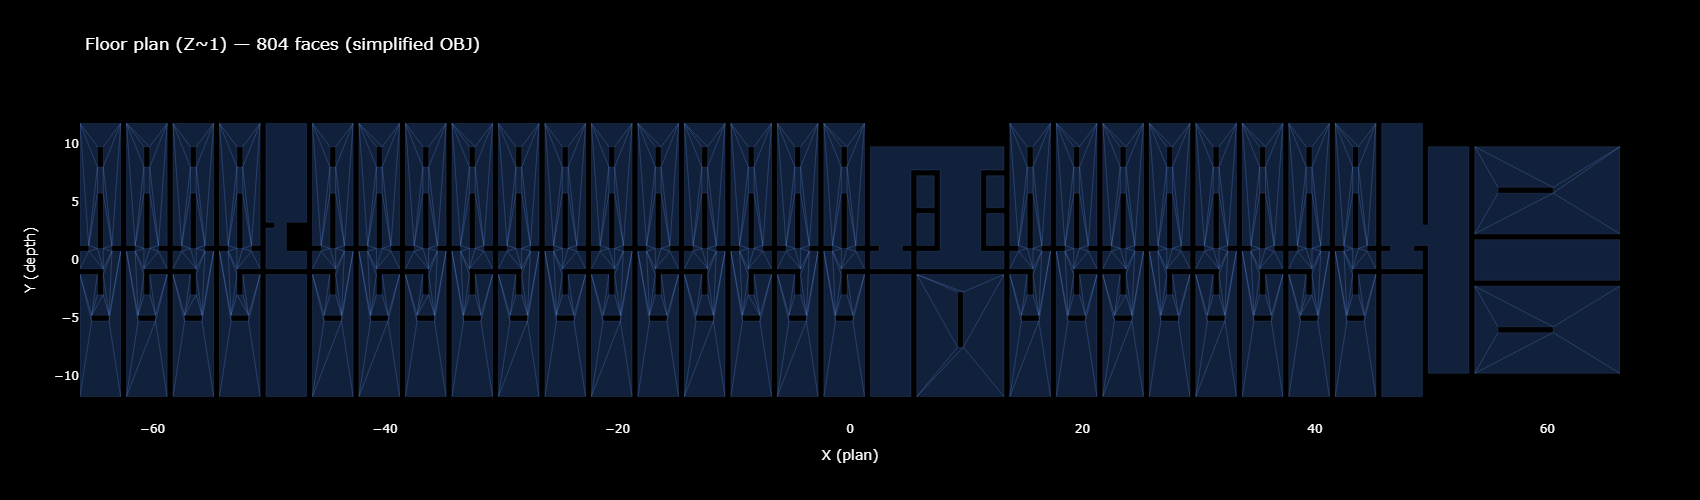

Saved: E:/IAAC Local GIT Repositories/Graph ML - Environment/Final_Project\Notebooks\assets\assets_marsella_grids_single_floor\01_floor_plan_raw.png


In [6]:
fig = go.Figure()
for f in building_faces:
    vs = Topology.Vertices(f)
    xs = [Vertex.X(v) - XMID for v in vs] + [Vertex.X(vs[0]) - XMID]
    ys = [Vertex.Y(v) - YMID for v in vs] + [Vertex.Y(vs[0]) - YMID]  # plan Y depth
    fig.add_trace(go.Scatter(
        x=xs, y=ys, mode="lines", fill="toself",
        fillcolor="rgba(70,130,235,0.25)",
        line=dict(color="rgba(120,170,255,0.35)", width=0.4),
        showlegend=False))
fig.update_layout(
    title=dict(
        text=f"Floor plan (Z~{FLOOR_Z}) — {len(building_faces)} faces (simplified OBJ)",
        font=dict(color="white")),
    xaxis=dict(scaleanchor="y", scaleratio=1,
               showgrid=False, zeroline=False, color="white",
               title=dict(text="X (plan)", font=dict(color="white"))),
    yaxis=dict(showgrid=False, zeroline=False, color="white",
               title=dict(text="Y (depth)", font=dict(color="white"))),
    paper_bgcolor="black", plot_bgcolor="black",
    width=1700, height=500,
)
fig.show(renderer=renderer)
save_fig(fig, "01_floor_plan_raw.png")

## 9. Build the graph from sliced face cells

Each sliced face → one topologicpy `Vertex` at its centroid, projected to the XY display
plane: `display_X = building_X − XMID`,  `display_Y = building_Z − ZMID`.

**Efficient adjacency detection:** instead of the O(n²) `faces_are_adjacent` loop from the
team notebook, we build an edge-map in O(n·e): two sliced faces that share a topologicpy
`Edge` (same vertex coordinates) are connected as graph neighbours.

In [7]:
from collections import defaultdict as _defaultdict

t0 = time.time()
all_v         = []
display_cells = []   # display Face for each sliced face (projected to XY plane)
cell_lookup   = {}   # rk(dx, dy) -> display Face

for f in sliced_faces:
    centroid = Topology.Centroid(f)
    cx = Vertex.X(centroid)   # plan X
    cy = Vertex.Y(centroid)   # plan Y (depth)
    dx, dy = cx - XMID, cy - YMID
    all_v.append(Vertex.ByCoordinates(float(dx), float(dy), 0.0))
    # Project face from XY building plane to XY display plane
    verts = Topology.Vertices(f)
    if len(verts) >= 3:
        dv = [Vertex.ByCoordinates(Vertex.X(v) - XMID, Vertex.Y(v) - YMID, 0.0)
              for v in verts]
        try:
            disp = Face.ByWire(Wire.ByVertices(dv, close=True))
        except Exception:
            disp = None
    else:
        disp = None
    display_cells.append(disp)
    if disp:
        cell_lookup[rk(dx, dy)] = disp

print(f"Graph vertices    : {len(all_v)}")
print(f"Display faces OK  : {sum(1 for d in display_cells if d)}")

# Edge-map adjacency  O(n*e) — two faces sharing an edge are graph neighbours
edge_map = _defaultdict(list)
for i, f in enumerate(sliced_faces):
    for e in (Topology.Edges(f) or []):
        vs = Topology.Vertices(e)
        if len(vs) < 2:
            continue
        k1 = tuple(round(c, 3) for c in [Vertex.X(vs[0]), Vertex.Y(vs[0]), Vertex.Z(vs[0])])
        k2 = tuple(round(c, 3) for c in [Vertex.X(vs[1]), Vertex.Y(vs[1]), Vertex.Z(vs[1])])
        edge_map[frozenset([k1, k2])].append(i)

all_e, _seen = [], set()
for idxs in edge_map.values():
    if len(idxs) >= 2:
        for a in range(len(idxs)):
            for b in range(a + 1, len(idxs)):
                pair = frozenset([idxs[a], idxs[b]])
                if pair not in _seen:
                    _seen.add(pair)
                    all_e.append(Edge.ByVertices([all_v[idxs[a]], all_v[idxs[b]]]))

print(f"Graph edges       : {len(all_e)}  ({time.time()-t0:.1f}s)")

# Triangulate display faces for VGA sight-line testing
PLAN_TRIS = extract_triangles_display([d for d in display_cells if d])
print(f"VGA plan triangles: {len(PLAN_TRIS)}")

# Bounding-box Face for Isovist (XY plane)
PLAN_FACE = make_rect_face(XMIN - XMID, YMIN - YMID, XMAX - XMID, YMAX - YMID)

def heatmap_from_graph(values, title, filename, colorScale):
    fv = []
    for v, val in zip(gverts, values):
        f = cell_lookup.get(rk(Vertex.X(v), Vertex.Y(v)))
        if f is not None:
            fv.append((f, val))
    return show_face_heatmap(fv, title, filename, colorScale)

Graph vertices    : 804
Display faces OK  : 804
Graph edges       : 841  (1.4s)
VGA plan triangles: 926


## 9b. Build the graph

Run this cell after cell 9 (adjacency detection) completes.
Creates the topologicpy  from the vertex/edge lists.

In [8]:
t0 = time.time()
building_graph = Graph.ByVerticesEdges(all_v, all_e)
gverts = Graph.Vertices(building_graph)
gedges = Graph.Edges(building_graph)
print(f"Building graph: {len(gverts)} vertices, {len(gedges)} edges  ({time.time()-t0:.1f}s)")
print(f"Graph density:  {Graph.Density(building_graph):.5f}")

Building graph: 804 vertices, 841 edges  (1.5s)
Graph density:  0.00261


## 10. Show the single-floor graph

Orthographic top-down view of the 3 300-node, 4-connected grid graph.
All nodes lie in the XY plane at Z = 0.

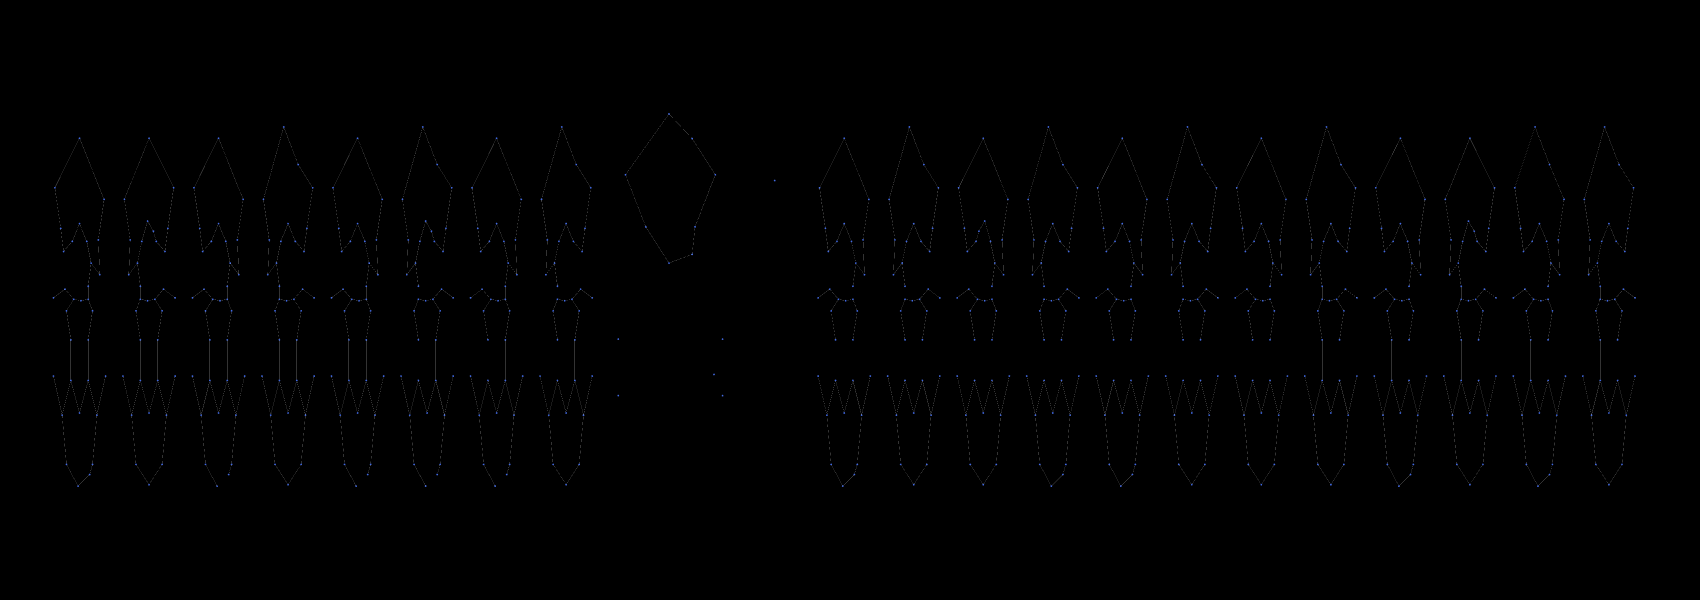

Saved: E:/IAAC Local GIT Repositories/Graph ML - Environment/Final_Project\Notebooks\assets\assets_marsella_grids_single_floor\03_floor_graph.png


In [9]:
fig = Topology.Show(
    building_graph,
    vertexSize=2, vertexColor="royalblue",
    edgeColor="rgba(200,220,255,0.4)", edgeWidth=0.5,
    backgroundColor="black",
    width=1700, height=600,
    showFigure=False, renderer=renderer,
)
_ax  = dict(showbackground=False, showgrid=True,
            gridcolor="rgba(255,255,255,0.12)", zeroline=False, color="white")
_axz = {**_ax, "showgrid": False}
fig.update_layout(
    scene=dict(
        aspectmode="data",
        xaxis=dict(**_ax,  title=dict(text="x", font=dict(color="white"))),
        yaxis=dict(**_ax,  title=dict(text="y", font=dict(color="white"))),
        zaxis=dict(**_axz, title=dict(text="z", font=dict(color="white"))),
    ),
    scene_camera=dict(projection=dict(type="orthographic"),
                      eye=dict(x=0.0, y=0.0, z=3.5)),
    scene_dragmode="orbit",
)
fig.show(renderer=INTERACTIVE_RENDERER)
save_fig(fig, "03_floor_graph.png")

## 11. Minimum Spanning Tree

The MST connects all 3 300 cells with the fewest edges — the irreducible circulation
skeleton.  Density ratio (original / MST) measures how much redundancy the grid provides.

Minimum Spanning Tree: 804 vertices, 766 edges  (1.6s)
Original graph  — Density: 0.00261
MST             — Density: 0.00237


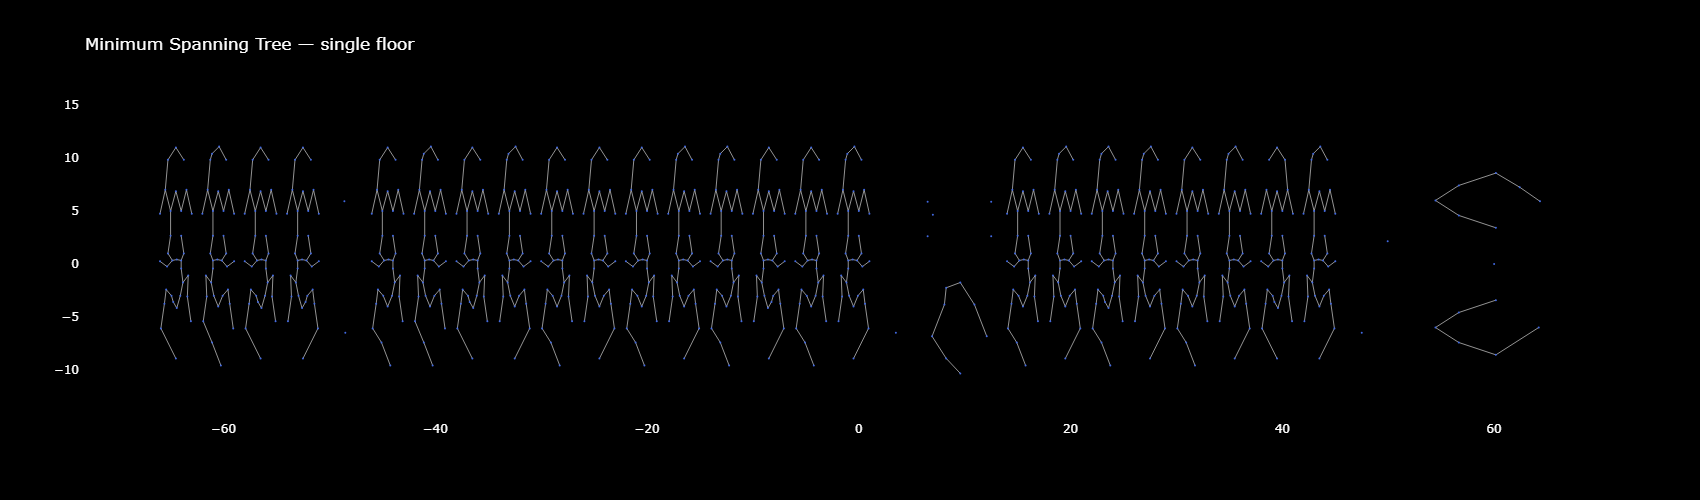

Saved: E:/IAAC Local GIT Repositories/Graph ML - Environment/Final_Project\Notebooks\assets\assets_marsella_grids_single_floor\10_mst.png


In [10]:
t0 = time.time()
mst = Graph.MinimumSpanningTree(building_graph)
mst_verts = Graph.Vertices(mst)
mst_edges = Graph.Edges(mst)
print(f"Minimum Spanning Tree: {len(mst_verts)} vertices, {len(mst_edges)} edges  ({time.time()-t0:.1f}s)")
print(f"Original graph  — Density: {Graph.Density(building_graph):.5f}")
print(f"MST             — Density: {Graph.Density(mst):.5f}")

ex, ey = [], []
for e in mst_edges:
    vs_e = Topology.Vertices(e)
    if len(vs_e) >= 2:
        ex += [Vertex.X(vs_e[0]), Vertex.X(vs_e[1]), None]
        ey += [Vertex.Y(vs_e[0]), Vertex.Y(vs_e[1]), None]

fig = go.Figure()
fig.add_trace(go.Scatter(x=ex, y=ey, mode="lines",
                         line=dict(color="lightgrey", width=0.7), showlegend=False))
fig.add_trace(go.Scatter(x=[Vertex.X(v) for v in mst_verts],
                         y=[Vertex.Y(v) for v in mst_verts],
                         mode="markers", marker=dict(size=2, color="royalblue"),
                         showlegend=False))
fig.update_layout(
    title=dict(text="Minimum Spanning Tree — single floor", font=dict(color="white")),
    xaxis=dict(scaleanchor="y", scaleratio=1, showgrid=False, zeroline=False, color="white"),
    yaxis=dict(showgrid=False, zeroline=False, color="white"),
    paper_bgcolor="black", plot_bgcolor="black",
    width=1700, height=500,
)
fig.show(renderer=INTERACTIVE_RENDERER)
save_fig(fig, "10_mst.png")

## 12. Shortest Path — end to end

Navigate from the **left end** to the **right end** of the floor plan along the shortest
sequence of adjacent cells.

In [11]:
def graph_closest(x, y):
    best, bd = None, 1e18
    for v in gverts:
        d = (Vertex.X(v) - x) ** 2 + (Vertex.Y(v) - y) ** 2
        if d < bd:
            bd, best = d, v
    return best

X_HALF  = XMAX - XMID   # 66.25
start_v = graph_closest(-X_HALF + 0.5, 0.0)
end_v   = graph_closest( X_HALF - 0.5, 0.0)

t0 = time.time()
path = Graph.ShortestPath(building_graph, vertexA=start_v, vertexB=end_v)

if path is None:
    print("No path found — check graph connectivity.")
else:
    path_len   = Wire.Length(path)
    path_verts = Topology.Vertices(path)
    path_edges = Topology.Edges(path)
    print(f"Shortest path  ({time.time()-t0:.1f}s)")
    print(f"  Length : {path_len:.2f}")
    print(f"  Nodes  : {len(path_verts)}")
    print(f"  Edges  : {len(path_edges)}")

    px = [Vertex.X(v) for v in path_verts]
    py = [Vertex.Y(v) for v in path_verts]

    fig = go.Figure()
    fig.add_shape(type="rect",
                  x0=XMIN - XMID, y0=YMIN - YMID,
                  x1=XMAX - XMID, y1=YMAX - YMID,
                  line=dict(color="rgba(255,255,255,0.20)", width=1))
    fig.add_trace(go.Scatter(x=px, y=py, mode="lines+markers",
                             line=dict(color="red", width=3),
                             marker=dict(size=3, color="red"),
                             name=f"Path  L = {path_len:.0f}"))
    for v, col, lbl in [(start_v, "cyan", "Start"), (end_v, "orange", "End")]:
        fig.add_trace(go.Scatter(
            x=[Vertex.X(v)], y=[Vertex.Y(v)], mode="markers+text",
            marker=dict(size=13, color=col, symbol="diamond"),
            text=[lbl], textposition="top center",
            textfont=dict(color=col, size=12), showlegend=False))
    fig.update_layout(
        title=dict(text=f"Shortest path — left to right  (length {path_len:.0f})",
                   font=dict(color="white")),
        xaxis=dict(scaleanchor="y", scaleratio=1, showgrid=False, zeroline=False, color="white"),
        yaxis=dict(showgrid=False, zeroline=False, color="white"),
        paper_bgcolor="black", plot_bgcolor="black",
        legend=dict(font=dict(color="white"), bgcolor="rgba(0,0,0,0.6)"),
        width=1700, height=500,
    )
    fig.show(renderer=INTERACTIVE_RENDERER)
    save_fig(fig, "08_shortest_path.png")

No path found — check graph connectivity.


## 13. Degree Centrality

Hub / dead-end map.  Corner cells have degree 2, edge cells degree 3, interior cells
degree 4.  Cells at the ends of the narrow slab naturally score lowest.

Degree centrality — 804 nodes  (3.4s)
  Range : 0.0000 – 0.0037
  Mean  : 0.0026   Std: 0.0007

Top 5 most connected (hubs):
  plan (333.50, 24.00)  ->  0.0037  (3 links)
  plan (334.00, 22.00)  ->  0.0037  (3 links)
  plan (334.17, 17.33)  ->  0.0037  (3 links)
  plan (335.00, 22.00)  ->  0.0037  (3 links)
  plan (335.50, 24.00)  ->  0.0037  (3 links)

Top 5 least connected (dead ends):
  plan (246.42, 22.92)  ->  0.0000  (0 links)
  plan (342.50, 10.50)  ->  0.0000  (0 links)
  plan (301.50, 19.62)  ->  0.0000  (0 links)
  plan (301.50, 22.88)  ->  0.0000  (0 links)
  plan (301.99, 21.66)  ->  0.0000  (0 links)


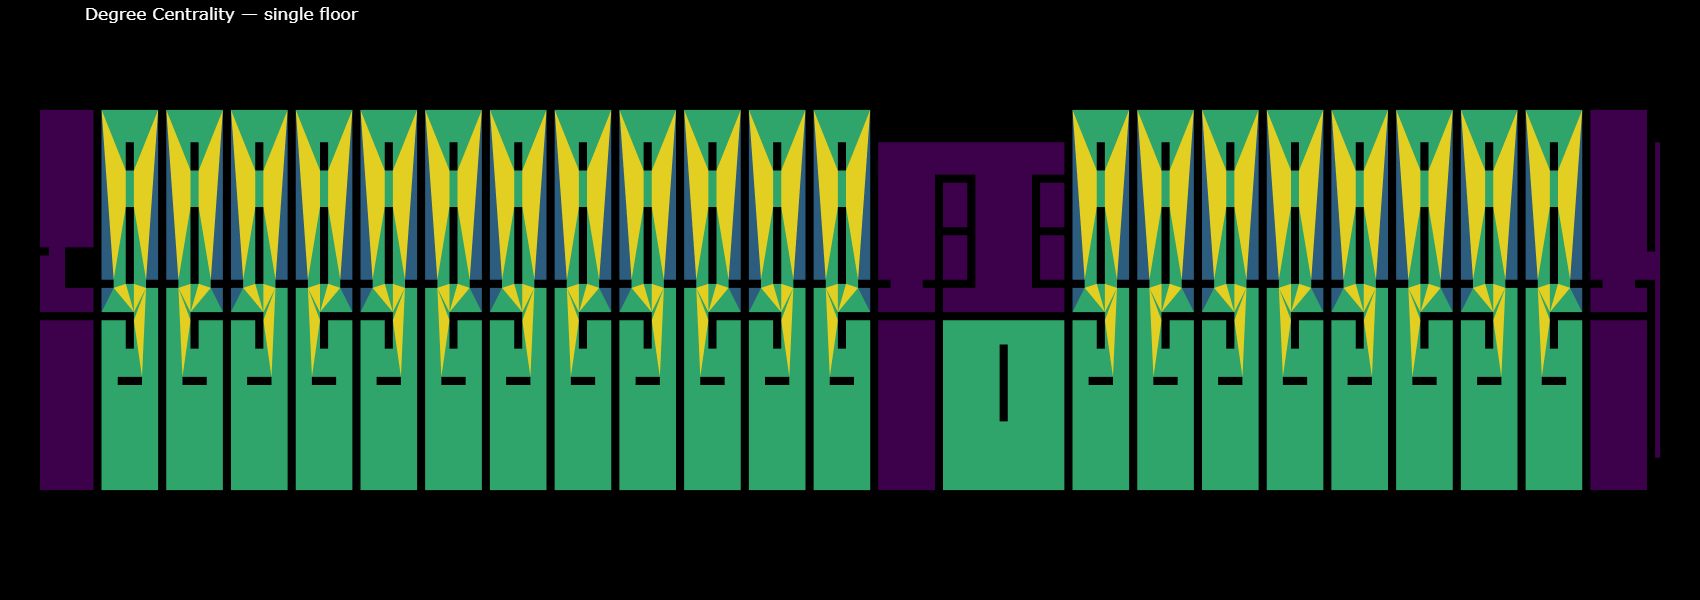

Saved: E:/IAAC Local GIT Repositories/Graph ML - Environment/Final_Project\Notebooks\assets\assets_marsella_grids_single_floor\04_degree_centrality.png


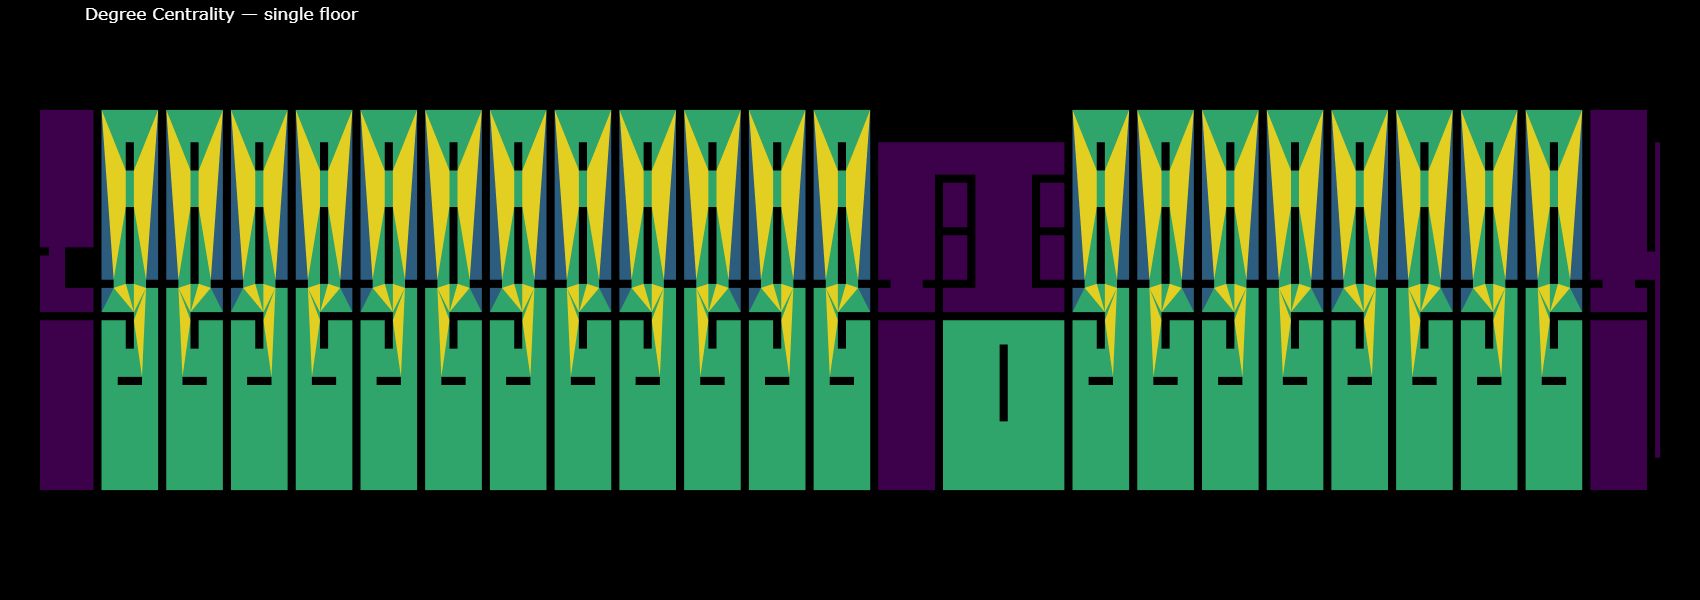

In [12]:
t0 = time.time()
degree_values = Graph.DegreeCentrality(building_graph, normalize=True)
n_nodes = len(degree_values)
a = np.array(degree_values, dtype=float)
print(f"Degree centrality — {n_nodes} nodes  ({time.time()-t0:.1f}s)")
print(f"  Range : {a.min():.4f} – {a.max():.4f}")
print(f"  Mean  : {a.mean():.4f}   Std: {a.std():.4f}")

sorted_dc = sorted(zip(gverts, degree_values), key=lambda x: x[1], reverse=True)
print("\nTop 5 most connected (hubs):")
for v, score in sorted_dc[:5]:
    links = round(score * (n_nodes - 1))
    print(f"  plan ({Vertex.X(v)+XMID:.2f}, {Vertex.Y(v)+YMID:.2f})  ->  {score:.4f}  ({links} links)")
print("\nTop 5 least connected (dead ends):")
for v, score in sorted_dc[-5:]:
    links = round(score * (n_nodes - 1))
    print(f"  plan ({Vertex.X(v)+XMID:.2f}, {Vertex.Y(v)+YMID:.2f})  ->  {score:.4f}  ({links} links)")

heatmap_from_graph(degree_values, "Degree Centrality — single floor",
                   "04_degree_centrality.png", "viridis")

## 14. Closeness Centrality (Integration)

How close each cell is to every other cell.  High values mark globally integrated,
easy-to-reach locations — typically cells near the geometric centre of the slab.

Closeness centrality — 804 nodes  (0.6s)
  Range : 0.0000 – 0.0092
  Mean  : 0.0064   Std: 0.0015

Top 5 most integrated (closest to all):
  plan (319.00, 17.33)  ->  0.0092
  plan (283.00, 17.33)  ->  0.0091
  plan (254.00, 17.33)  ->  0.0091
  plan (234.00, 17.33)  ->  0.0091
  plan (338.00, 17.33)  ->  0.0091


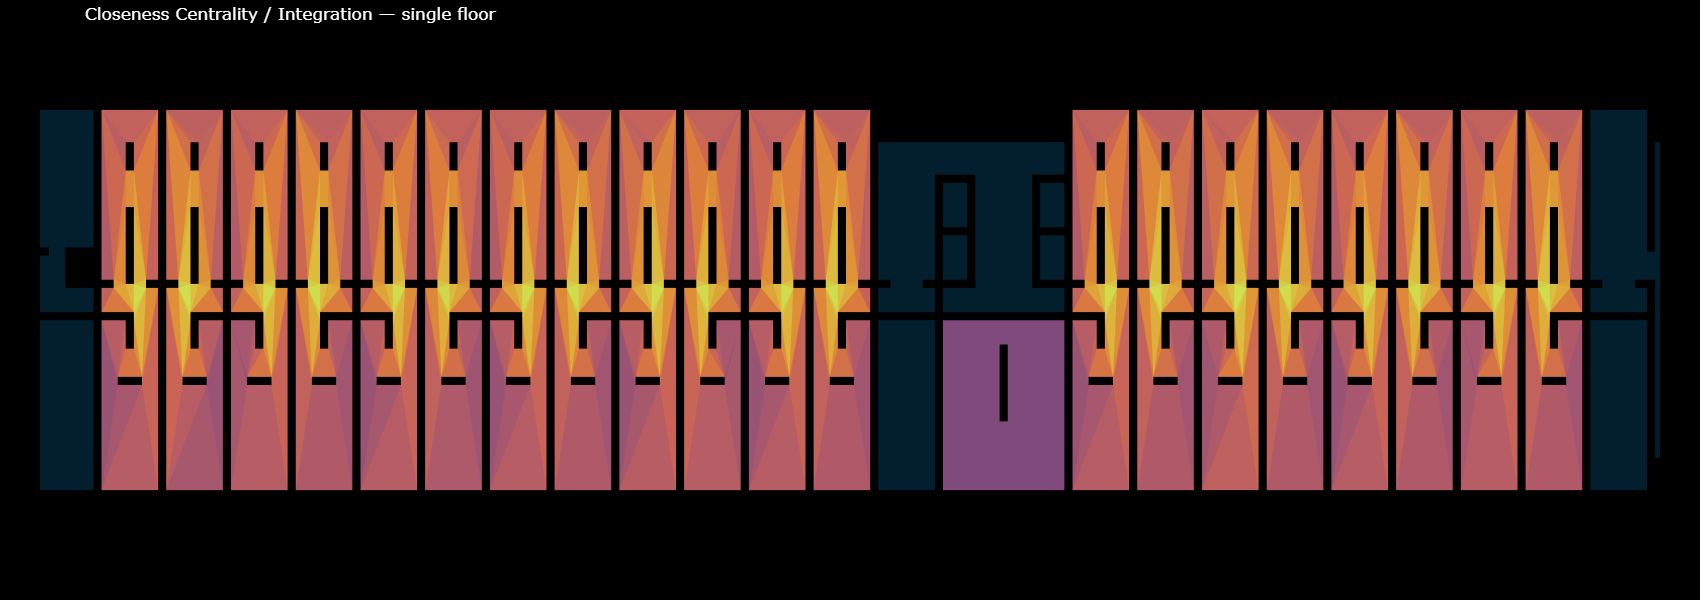

Saved: E:/IAAC Local GIT Repositories/Graph ML - Environment/Final_Project\Notebooks\assets\assets_marsella_grids_single_floor\05_closeness_centrality.png


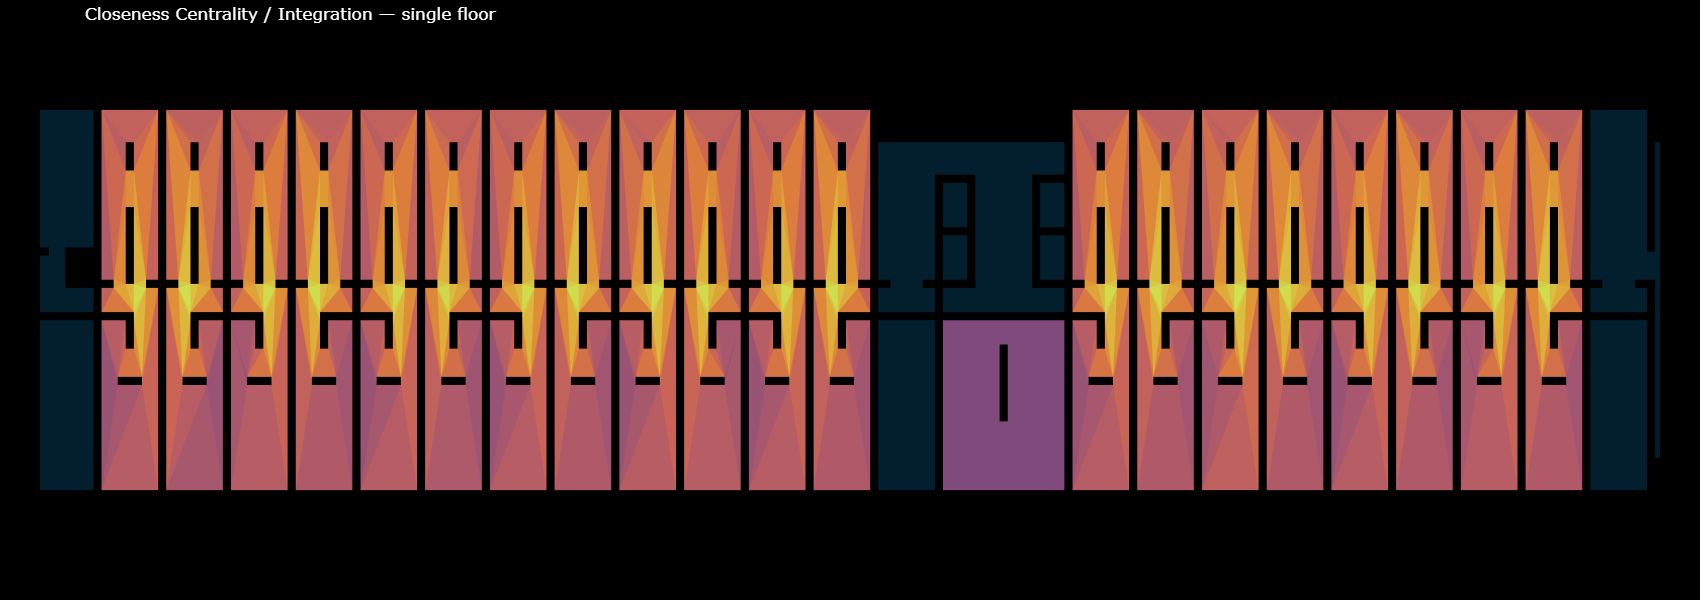

In [13]:
t0 = time.time()
closeness_values = Graph.ClosenessCentrality(building_graph)
a = np.array(closeness_values, dtype=float)
print(f"Closeness centrality — {len(closeness_values)} nodes  ({time.time()-t0:.1f}s)")
print(f"  Range : {a.min():.4f} – {a.max():.4f}")
print(f"  Mean  : {a.mean():.4f}   Std: {a.std():.4f}")

sorted_cc = sorted(zip(gverts, closeness_values), key=lambda x: x[1], reverse=True)
print("\nTop 5 most integrated (closest to all):")
for v, score in sorted_cc[:5]:
    print(f"  plan ({Vertex.X(v)+XMID:.2f}, {Vertex.Y(v)+YMID:.2f})  ->  {score:.4f}")

heatmap_from_graph(closeness_values, "Closeness Centrality / Integration — single floor",
                   "05_closeness_centrality.png", "thermal")

## 15. Betweenness Centrality (Choice)

How often each cell lies on the shortest paths between every other pair of cells.
High values = critical circulation corridors.

Betweenness centrality — 804 nodes  (0.8s)
  Range : 0.0000 – 0.0009
  Mean  : 0.0002   Std: 0.0002

Top 5 most traversed (critical paths):
  plan (319.00, 17.33)  ->  0.0009
  plan (283.00, 17.33)  ->  0.0009
  plan (254.00, 17.33)  ->  0.0009
  plan (234.00, 17.33)  ->  0.0009
  plan (319.17, 15.25)  ->  0.0009


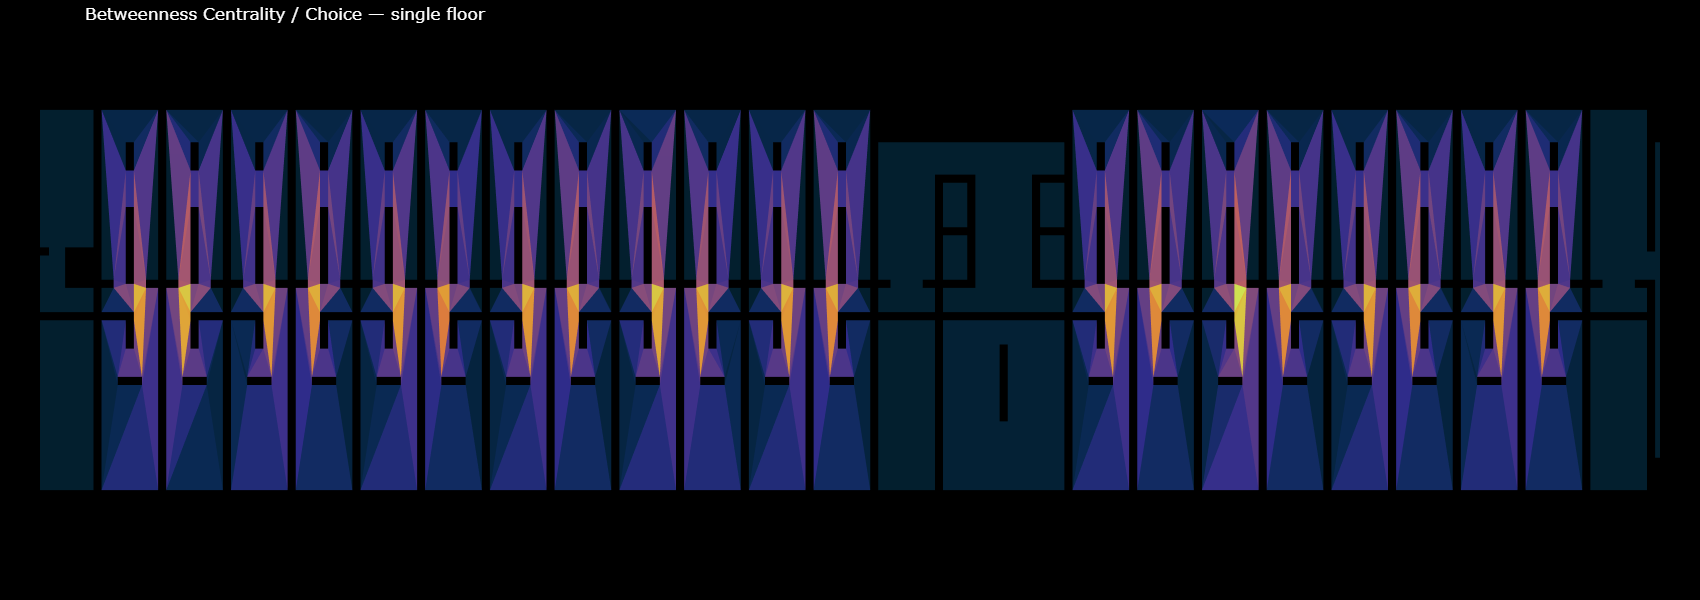

Saved: E:/IAAC Local GIT Repositories/Graph ML - Environment/Final_Project\Notebooks\assets\assets_marsella_grids_single_floor\06_betweenness_centrality.png


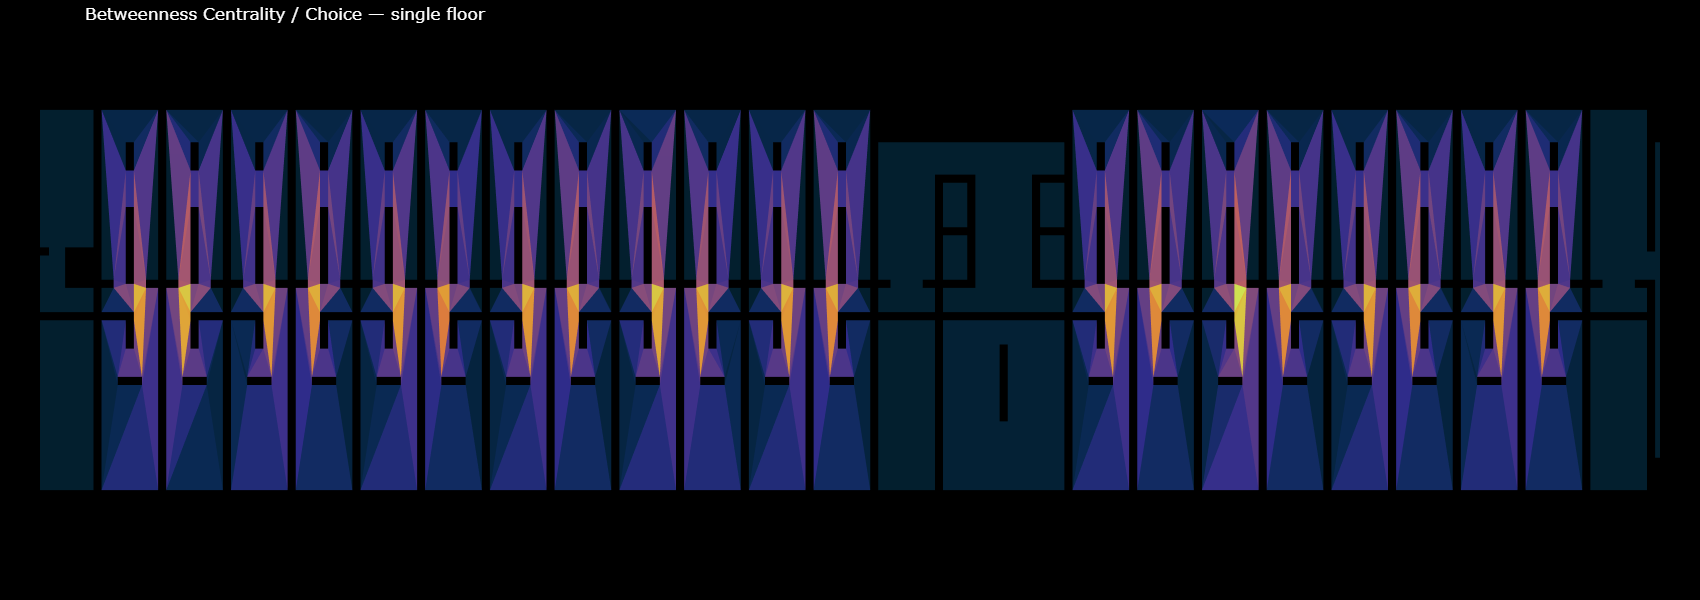

In [14]:
t0 = time.time()
betweenness_values = Graph.BetweennessCentrality(building_graph, normalize=True)
a = np.array(betweenness_values, dtype=float)
print(f"Betweenness centrality — {len(betweenness_values)} nodes  ({time.time()-t0:.1f}s)")
print(f"  Range : {a.min():.4f} – {a.max():.4f}")
print(f"  Mean  : {a.mean():.4f}   Std: {a.std():.4f}")

sorted_bc = sorted(zip(gverts, betweenness_values), key=lambda x: x[1], reverse=True)
print("\nTop 5 most traversed (critical paths):")
for v, score in sorted_bc[:5]:
    print(f"  plan ({Vertex.X(v)+XMID:.2f}, {Vertex.Y(v)+YMID:.2f})  ->  {score:.4f}")

heatmap_from_graph(betweenness_values, "Betweenness Centrality / Choice — single floor",
                   "06_betweenness_centrality.png", "thermal")

## 16. Community Detection

Partition the floor into spatial communities.  Community structure here reflects the
irregular spacing of the grid lines: zones with closer-spaced lines (finer spatial
resolution) tend to cluster together, while coarser zones form separate communities.

Detected 38 communities  (1.7s)

  ID   Cells
    0        1
    1        1
    2        1
    3        8
    4        1
    5        1
    6        1
    7        1
    8        6
    9        7
   10       32
   11       32
   12       34
   13       32
   14       32
   15       32
   16       33
   17       32
   18       32
   19       32
   20       32
   21       32
   22        1
   23        1
   24        1
   25        1
   26       32
   27       32
   28       32
   29       32
   30       31
   31       32
   32       32
   33       32
   34       32
   35       33
   36       32
   37       33

Total navigable cells: 804


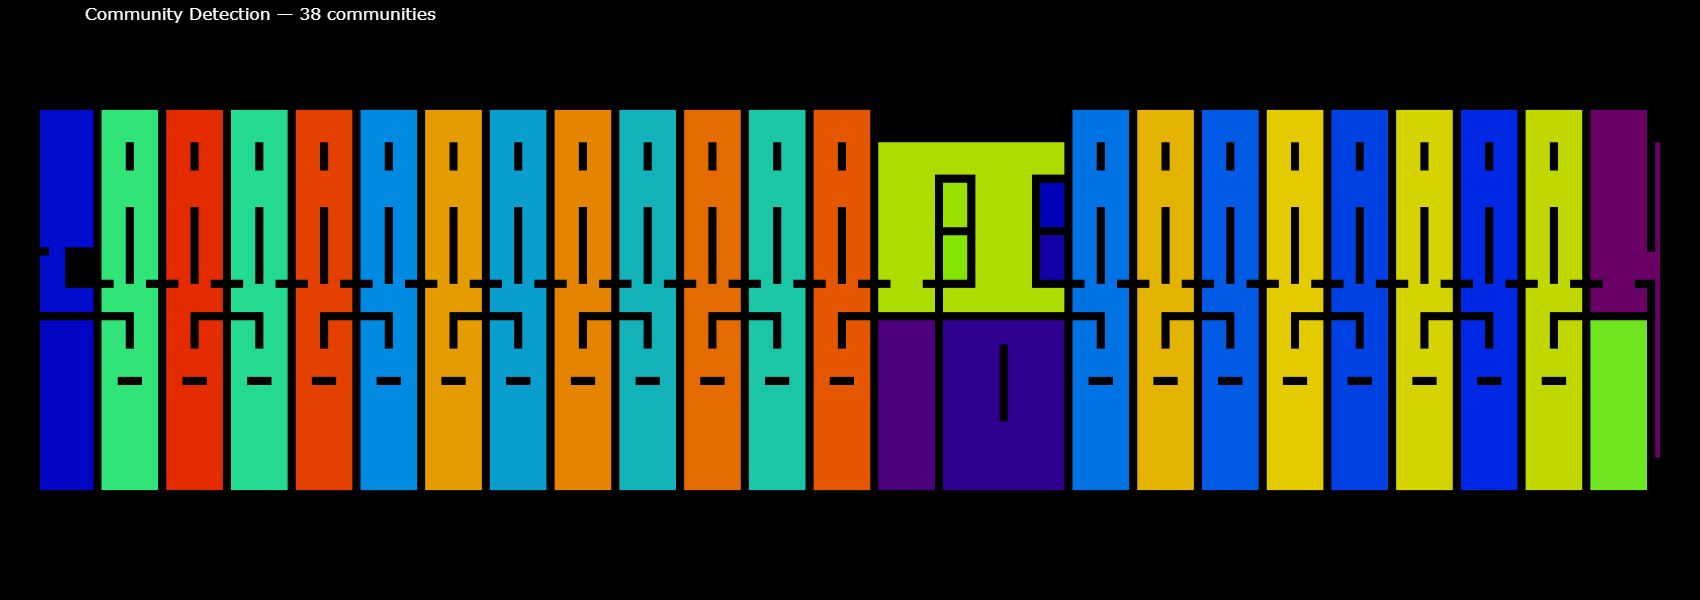

Saved: E:/IAAC Local GIT Repositories/Graph ML - Environment/Final_Project\Notebooks\assets\assets_marsella_grids_single_floor\07_communities.png


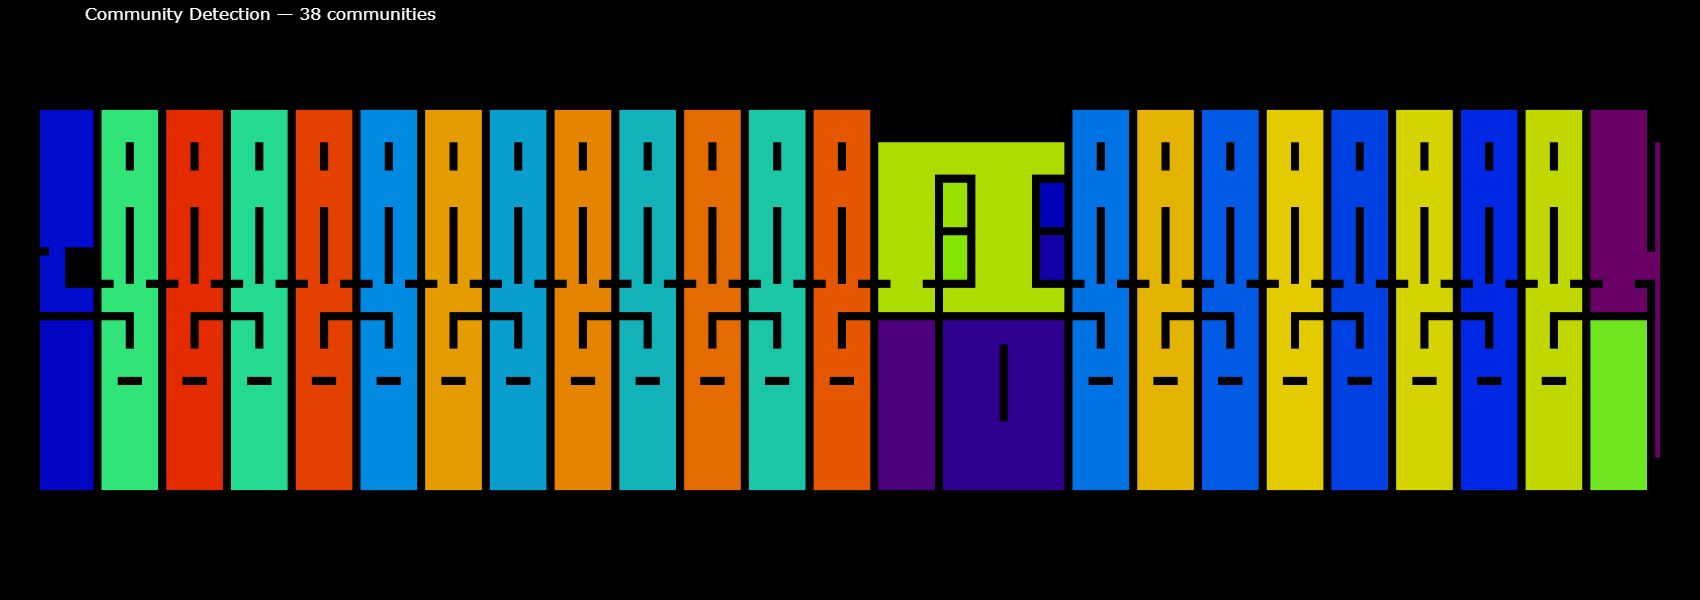

In [15]:
from collections import Counter
t0 = time.time()
community_values = Graph.CommunityPartition(building_graph)
n_comm = len(set(community_values))
community_counts = Counter(community_values)
print(f"Detected {n_comm} communities  ({time.time()-t0:.1f}s)")
print(f"\n{'ID':>4}  {'Cells':>6}")
for cid, cnt in sorted(community_counts.items()):
    print(f"  {cid:>3}    {cnt:>5}")
print(f"\nTotal navigable cells: {len(community_values)}")

heatmap_from_graph(community_values, f"Community Detection — {n_comm} communities",
                   "07_communities.png", "rainbow")

## 17. Visibility Graph Analysis / VGA (single floor)

Every `VGA_SUBSAMPLE`-th cell is used as a viewpoint.  The bounding rectangle of the
grid serves as the floor plan boundary for sight-line testing.

> **Note on open plans.**  `Marsella_grids.obj` contains no internal wall geometry.
> The bounding rectangle is obstacle-free, so VGA scores are nearly uniform — all
> viewpoints see all others, with slight edge effects at the slab ends.  To obtain
> spatially differentiated VGA, import wall/partition geometry separately.

VGA viewpoints: 161
VGA done  (10.0s)
  Degree — min: 160, max: 160, mean: 160.0


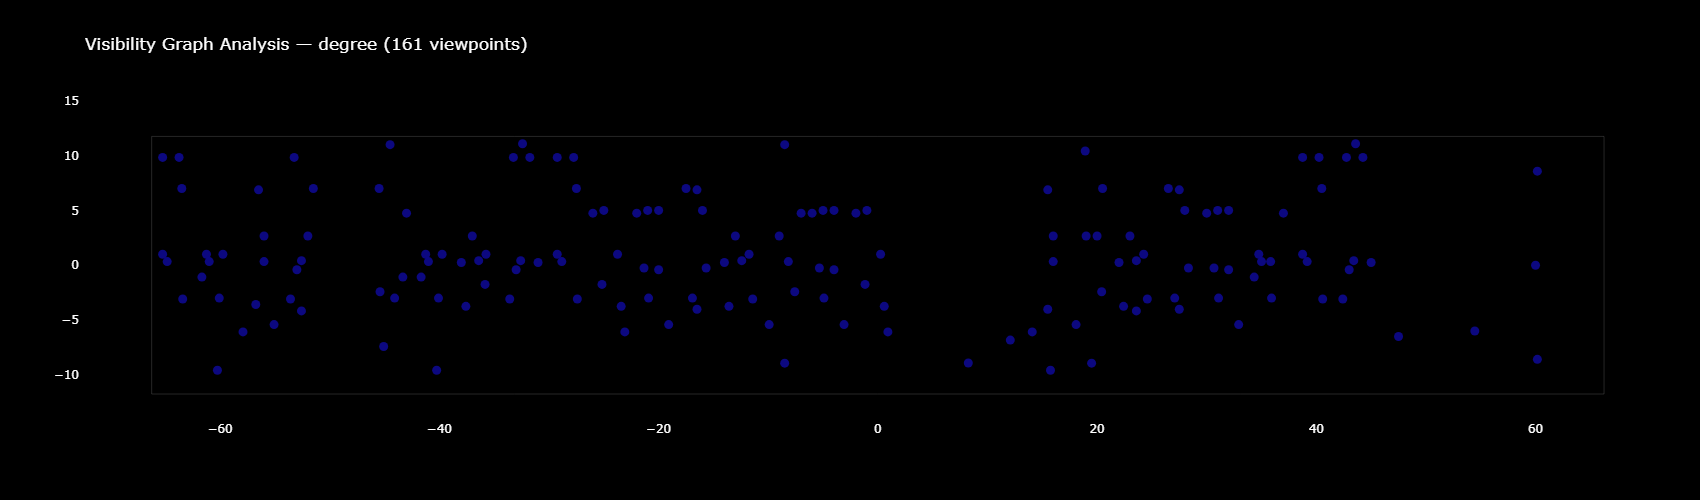

Saved: E:/IAAC Local GIT Repositories/Graph ML - Environment/Final_Project\Notebooks\assets\assets_marsella_grids_single_floor\09_visibility_vga.png


In [16]:
vga_pts = np.array([
    [Vertex.X(all_v[i]), Vertex.Y(all_v[i])]
    for i in range(0, len(all_v), VGA_SUBSAMPLE)
])
print(f"VGA viewpoints: {len(vga_pts)}")

ts_vga   = np.linspace(0.12, 0.88, VIS_SAMPLES)
deg_vga  = np.zeros(len(vga_pts), int)
t0 = time.time()
for ii in range(len(vga_pts)):
    for jj in range(ii + 1, len(vga_pts)):
        seg = (vga_pts[ii][None, :] * (1 - ts_vga)[:, None]
               + vga_pts[jj][None, :] * ts_vga[:, None])
        if points_inside_tris(PLAN_TRIS, seg).all():
            deg_vga[ii] += 1
            deg_vga[jj] += 1
print(f"VGA done  ({time.time()-t0:.1f}s)")
print(f"  Degree — min: {deg_vga.min()}, max: {deg_vga.max()}, mean: {deg_vga.mean():.1f}")

mn_v, mx_v = float(deg_vga.min()), float(deg_vga.max())
if mx_v == mn_v: mx_v = mn_v + 1e-9
colors_vga = [
    Color.AnyToHex(Color.ByValueInRange(float(d), minValue=mn_v, maxValue=mx_v,
                                         colorScale="plasma"))
    for d in deg_vga
]

vga_fig = go.Figure()
vga_fig.add_shape(type="rect",
                  x0=XMIN - XMID, y0=YMIN - YMID,
                  x1=XMAX - XMID, y1=YMAX - YMID,
                  line=dict(color="rgba(255,255,255,0.15)", width=1))
vga_fig.add_trace(go.Scatter(
    x=vga_pts[:, 0], y=vga_pts[:, 1], mode="markers",
    marker=dict(size=9, color=colors_vga, opacity=0.95),
    showlegend=False))
vga_fig.update_layout(
    title=dict(text=f"Visibility Graph Analysis — degree ({len(vga_pts)} viewpoints)",
               font=dict(color="white")),
    xaxis=dict(scaleanchor="y", scaleratio=1, showgrid=False, zeroline=False, color="white"),
    yaxis=dict(showgrid=False, zeroline=False, color="white"),
    paper_bgcolor="black", plot_bgcolor="black",
    width=1700, height=500,
)
vga_fig.show(renderer=renderer)
save_fig(vga_fig, "09_visibility_vga.png")

## 18. Isovist Analysis (single floor)

`Face.Isovist` casts rays from selected viewpoints against the bounding-box floor plan
face and returns the exact geometric polygon visible from each point.  For an open
rectangular plan, each isovist covers the entire rectangle.

Running Isovist Analysis...
Isovist viewpoints: 24
Valid isovists: 24 / 24
Visible cells — min: 804, max: 804, mean: 804.0


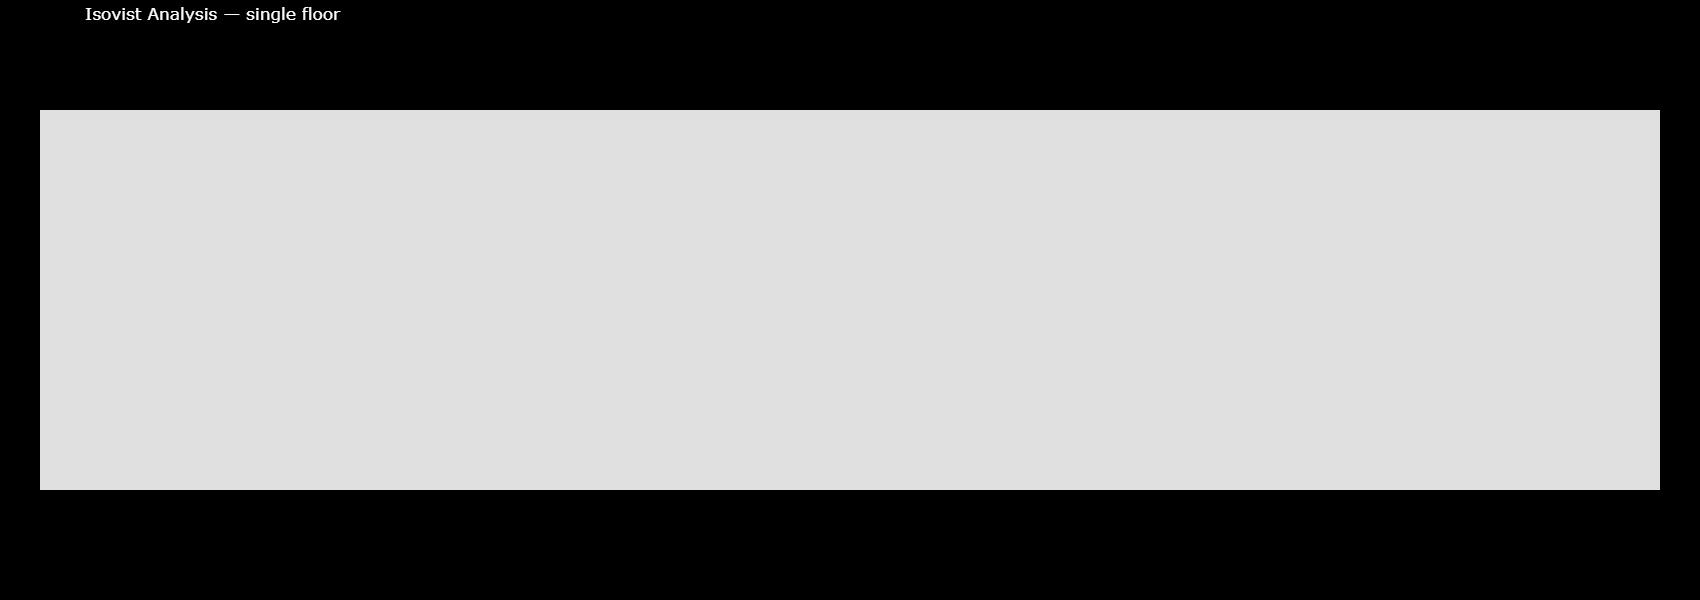

Saved: E:/IAAC Local GIT Repositories/Graph ML - Environment/Final_Project\Notebooks\assets\assets_marsella_grids_single_floor\11_isovists_floor.png


In [17]:
from topologicpy.Shell import Shell as _Shell

print("Running Isovist Analysis...")

# Sample ISO_ROWS * ISO_COLS viewpoints evenly from all sliced-face centroids
iso_step = max(1, len(all_v) // (ISO_ROWS * ISO_COLS))
iso_viewpoints = [
    Vertex.ByCoordinates(Vertex.X(all_v[i]), Vertex.Y(all_v[i]), 0.0)
    for i in range(iso_step // 2, len(all_v), iso_step)
]
print(f"Isovist viewpoints: {len(iso_viewpoints)}")

valid_isovists, iso_counts = [], []
for iv in iso_viewpoints:
    try:
        iso = Face.Isovist(PLAN_FACE, iv)
        if iso is None:
            continue
        iso_faces_list = (
            Topology.Faces(iso)
            if not Topology.IsInstance(iso, "Face")
            else [iso])
        if not iso_faces_list:
            continue
        iso_face = iso_faces_list[0]
        count = sum(1 for gv in gverts if Vertex.IsInternal2D(gv, iso_face))
        valid_isovists.append(iso_face)
        iso_counts.append(count)
    except Exception:
        pass

print(f"Valid isovists: {len(valid_isovists)} / {len(iso_viewpoints)}")
if iso_counts:
    print(f"Visible cells — min: {min(iso_counts)}, max: {max(iso_counts)}, "
          f"mean: {sum(iso_counts)/len(iso_counts):.1f}")

if valid_isovists:
    fig_iso = Topology.Show(
        [PLAN_FACE] + valid_isovists,
        faceOpacity=0.35, showEdges=False, showVertices=False,
        camera=[0, 0, 2.5], backgroundColor="black",
        width=1700, height=600,
        showFigure=False, renderer=renderer,
    )
    if fig_iso:
        fig_iso.update_layout(
            title=dict(text="Isovist Analysis — single floor", font=dict(color="white")))
        fig_iso.show(renderer=renderer)
        save_fig(fig_iso, "11_isovists_floor.png")
else:
    print("No valid isovists returned.")

## 19. Floor-wide Summary

In [18]:
G = globals()
print(f"{'Metric':<28}{'min':>10}{'max':>10}{'mean':>10}{'std':>10}")
for name, vals in [("Degree centrality",     degree_values),
                   ("Closeness centrality",   closeness_values),
                   ("Betweenness centrality", betweenness_values)]:
    a = np.array(vals, dtype=float)
    print(f"{name:<28}{a.min():>10.4f}{a.max():>10.4f}{a.mean():>10.4f}{a.std():>10.4f}")
n_comm_val = len(set(community_values)) if "community_values" in G else "N/A"
print()
print(f"Nodes      : {len(gverts)}")
print(f"Edges      : {len(gedges)}")
print(f"Density    : {Graph.Density(building_graph):.5f}")
print(f"Communities: {n_comm_val}")
if G.get("path") is not None:
    print(f"Path length: {path_len:.1f}")

Metric                             min       max      mean       std
Degree centrality               0.0000    0.0037    0.0026    0.0007
Closeness centrality            0.0000    0.0092    0.0064    0.0015
Betweenness centrality          0.0000    0.0009    0.0002    0.0002

Nodes      : 804
Edges      : 841
Density    : 0.00261
Communities: 38


## 20. Export analysis summary

Writes `analysis_summary.md` and `analysis_metadata.json` to `ASSETS_DIR`.
Re-run this cell after each full run to refresh the report.

In [19]:
import json as _json
from datetime import datetime

G = globals()

def _stats(arr):
    a = np.asarray(arr, dtype=float)
    if a.size == 0:
        return dict(n=0, min=None, max=None, mean=None, std=None)
    return dict(n=int(a.size), min=float(a.min()), max=float(a.max()),
                mean=float(a.mean()), std=float(a.std()))

meta = {}
meta["generated"]   = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
meta["notebook"]    = "Marsella_Grids_SingleFloor_Spatial_Intelligence.ipynb"
meta["description"] = ("Single-floor Spatial Intelligence analysis of the Marsella "
                       "building using pre-defined grid cells from Marsella_grids.obj.")
meta["parameters"] = {
    "BUILDING_OBJ_PATH": BUILDING_OBJ_PATH,
    "GRID_OBJ_PATH": GRID_OBJ_PATH,
    "FLOOR_Z": FLOOR_Z,
    "building_faces": len(building_faces),
    "sliced_faces": len(sliced_faces),
    "total_nodes": len(all_v),
    "VGA_SUBSAMPLE": VGA_SUBSAMPLE,
    "VIS_SAMPLES": VIS_SAMPLES,
}
meta["geometry"] = {
    "plan_bbox": {"x_min": float(XMIN), "x_max": float(XMAX),
                  "y_min": float(YMIN), "y_max": float(YMAX),
                  "width": float(XMAX - XMIN), "height": float(YMAX - YMIN)},
    "building_faces": len(building_faces),
    "sliced_faces": len(sliced_faces),
    "total_nodes": len(all_v),
}
meta["graph"] = {
    "nodes":   len(gverts),
    "edges":   len(gedges),
    "density": float(Graph.Density(building_graph)),
}
if "mst" in G:
    meta["mst"] = {"vertices": len(mst_verts), "edges": len(mst_edges),
                   "density": float(Graph.Density(mst))}
if G.get("path") is not None:
    meta["shortest_path"] = {
        "length": float(path_len),
        "n_nodes": len(Topology.Vertices(path)),
    }
meta["centrality"] = {}
for key, var in [("degree", "degree_values"), ("closeness", "closeness_values"),
                 ("betweenness", "betweenness_values")]:
    if var in G:
        meta["centrality"][key] = _stats(G[var])
if "degree_values" in G:
    top = sorted(zip(gverts, degree_values), key=lambda x: x[1], reverse=True)[:5]
    meta["centrality"]["top5_degree_hubs"] = [
        {"x_plan": round(Vertex.X(v) + XMID, 3), "y_plan": round(Vertex.Y(v) + YMID, 3),
         "score": round(float(sc), 6)}
        for v, sc in top]
if "community_values" in G:
    from collections import Counter as _C
    cc = _C(community_values)
    meta["communities"] = {
        "count": len(set(community_values)),
        "total_cells": len(community_values),
        "sizes": {str(k): int(v) for k, v in sorted(cc.items())},
    }

json_path = os.path.join(ASSETS_DIR, "analysis_metadata.json")
with open(json_path, "w", encoding="utf-8") as f:
    _json.dump(meta, f, ensure_ascii=False, indent=2)
print(f"Saved: {json_path}")

# Markdown
L = [f"# Analysis Summary — Marsella Grid Single Floor\n",
     f"_Generated: {meta['generated']}_\n",
     meta["description"] + "\n",
     "## Parameters\n", "| Parameter | Value |", "|---|---|",]
for k, v in meta["parameters"].items():
    L.append(f"| `{k}` | {v} |")
g = meta["geometry"]["plan_bbox"]
L += ["", "## Geometry\n",
      f"- **Plan bbox:** X [{g['x_min']:.2f}, {g['x_max']:.2f}]  "
      f"Y [{g['y_min']:.2f}, {g['y_max']:.2f}]  "
      f"({g['width']:.2f} x {g['height']:.2f} units)",
      f"- **Sliced cells:** {meta['geometry']['sliced_faces']} "  
      f"(from {meta['geometry']['building_faces']} building faces)", ""]
gr = meta["graph"]
L += ["## Graph\n",
      f"- Nodes: **{gr['nodes']}**  |  Edges: **{gr['edges']}**  "
      f"|  Density: **{gr['density']:.5f}**", ""]
if "centrality" in meta:
    L += ["## Centrality metrics\n",
          "| Metric | min | max | mean | std |", "|---|---|---|---|---|",]
    for key in ("degree", "closeness", "betweenness"):
        s = meta["centrality"].get(key)
        if s:
            L.append(f"| {key.capitalize()} | {s['min']:.4f} | {s['max']:.4f} | "
                     f"{s['mean']:.4f} | {s['std']:.4f} |")
    L.append("")
if "communities" in meta:
    cm = meta["communities"]
    L += ["## Community detection\n",
          f"- Communities: **{cm['count']}**  |  Total cells: {cm['total_cells']}", ""]
L.append("---\n_Generated automatically by section 20._")

md_path = os.path.join(ASSETS_DIR, "analysis_summary.md")
with open(md_path, "w", encoding="utf-8") as f:
    f.write("\n".join(L))
print(f"Saved: {md_path}")

Saved: E:/IAAC Local GIT Repositories/Graph ML - Environment/Final_Project\Notebooks\assets\assets_marsella_grids_single_floor\analysis_metadata.json
Saved: E:/IAAC Local GIT Repositories/Graph ML - Environment/Final_Project\Notebooks\assets\assets_marsella_grids_single_floor\analysis_summary.md


## 21. Git commit & push

In [20]:
import subprocess
from datetime import datetime

REPO_ROOT = "E:/IAAC Local GIT Repositories/Graph ML - Environment"
NB_PATH   = (os.path.abspath(__vsc_ipynb_file__)
             if "__vsc_ipynb_file__" in dir()
             else os.path.join(
                 REPO_ROOT,
                 "Final_Project", "Notebooks", "Spatial Intelligence",
                 "Marsella_Grids_SingleFloor_Spatial_Intelligence.ipynb"))

COMMIT_MSG = (f"Update Marsella grids single-floor outputs — "
              f"{datetime.now().strftime('%Y-%m-%d %H:%M')}")

def git(args, cwd=REPO_ROOT):
    r = subprocess.run(["git"] + args, cwd=cwd, capture_output=True, text=True)
    out = (r.stdout + r.stderr).strip()
    if out:
        print(out)
    return r.returncode

print(f"Repo root : {REPO_ROOT}")
print(f"Notebook  : {NB_PATH}")
print(f"Assets    : {ASSETS_DIR}")
print()
git(["add", NB_PATH])
git(["add", ASSETS_DIR])
git(["status", "--short"])
print()
rc = git(["commit", "-m", COMMIT_MSG])
if rc == 0:
    print("\nPushing...")
    git(["push", "origin", "main"])
else:
    print("Nothing to commit or commit failed.")

Repo root : E:/IAAC Local GIT Repositories/Graph ML - Environment
Notebook  : e:\IAAC Local GIT Repositories\Graph ML - Environment\Final_Project\Notebooks\Spatial Intelligence\Marsella_Grids_SingleFloor_Spatial_Intelligence.ipynb
Assets    : E:/IAAC Local GIT Repositories/Graph ML - Environment/Final_Project\Notebooks\assets\assets_marsella_grids_single_floor

M  "Final_Project/Notebooks/Spatial Intelligence/Marsella_Grids_SingleFloor_Spatial_Intelligence.ipynb"
A  Final_Project/Notebooks/assets/assets_marsella_grids_single_floor/01_floor_plan_raw.png
A  Final_Project/Notebooks/assets/assets_marsella_grids_single_floor/03_floor_graph.png
A  Final_Project/Notebooks/assets/assets_marsella_grids_single_floor/04_degree_centrality.png
A  Final_Project/Notebooks/assets/assets_marsella_grids_single_floor/05_closeness_centrality.png
A  Final_Project/Notebooks/assets/assets_marsella_grids_single_floor/06_betweenness_centrality.png
A  Final_Project/Notebooks/assets/assets_marsella_grids_single_